In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
total_start = time.time()

In [2]:
df = pd.read_csv('amazon_ecommerce_1M.csv')
df.head(10)

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed
5,U705397,P35203,Home,Decor,HP,6155.63,17.64,5069.65,3.3,22,360,S2139,5.0,2025-07-13,5,Bangalore,Mobile App,Credit Card,True,Returned
6,U498591,P46434,Home,Furniture,Adidas,1104.92,37.81,687.20,3.4,14,232,S6977,3.3,2026-02-10,1,Delhi,Mobile App,Debit Card,False,In Transit
7,U738720,P93227,Clothing,Kids,Sony,1899.42,63.23,698.36,3.3,18,87,S9751,4.3,2024-05-27,5,Delhi,Tablet,Credit Card,False,Delivered
8,U330283,P99733,Beauty,Makeup,Sony,3611.18,24.77,2716.69,3.9,17,166,S1916,3.8,2024-11-03,1,Chennai,Mobile App,UPI,False,In Transit
9,U694731,P51245,Beauty,Makeup,Apple,3826.65,8.46,3502.76,3.4,12,108,S9179,3.2,2024-12-27,1,Mumbai,Web,Cash on Delivery,False,Delivered


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   user_id             1000000 non-null  object 
 1   product_id          1000000 non-null  object 
 2   category            1000000 non-null  object 
 3   subcategory         1000000 non-null  object 
 4   brand               1000000 non-null  object 
 5   price               1000000 non-null  float64
 6   discount            1000000 non-null  float64
 7   final_price         1000000 non-null  float64
 8   rating              1000000 non-null  float64
 9   review_count        1000000 non-null  int64  
 10  stock               1000000 non-null  int64  
 11  seller_id           1000000 non-null  object 
 12  seller_rating       1000000 non-null  float64
 13  purchase_date       1000000 non-null  object 
 14  shipping_time_days  1000000 non-null  int64  
 15  location        

In [4]:
df.describe()

,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,13224.119093,28.996161,9938.876985,3.927226,32.626704,250.023345,3.750030,3.166389
std,18079.626921,14.681077,14271.885557,0.519443,43.382201,144.567038,0.722092,1.674178
min,200.030000,5.000000,101.460000,1.500000,0.000000,0.000000,2.500000,1.000000
25%,2700.147500,16.910000,1705.930000,3.600000,10.000000,125.000000,3.100000,2.000000
50%,4971.830000,28.070000,3790.795000,3.900000,20.000000,250.000000,3.800000,3.000000
75%,14134.482500,39.240000,10384.440000,4.300000,39.000000,375.000000,4.400000,5.000000
max,79999.700000,70.000000,75831.110000,5.000000,3408.000000,500.000000,5.000000,6.000000


In [5]:
df.isnull().sum()

user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df['category'].value_counts()

category
Home           200922
Electronics    200038
Sports         199889
Clothing       199824
Beauty         199327
Name: count, dtype: int64

In [8]:
df['subcategory'].value_counts()

subcategory
Decor         67260
Kitchen       67021
Kids          67006
Outdoor       66795
Fitness       66780
Skincare      66696
Furniture     66641
Men           66599
Makeup        66331
Cycling       66314
Haircare      66300
Women         66219
Mobile        50364
Laptop        50190
Camera        49771
Headphones    49713
Name: count, dtype: int64

In [9]:
df['brand'].value_counts()

brand
LG         83882
Puma       83627
Lenovo     83542
Samsung    83535
HP         83520
Sony       83479
Boat       83448
Nike       83316
Zara       83218
Apple      83119
Adidas     82902
H&M        82412
Name: count, dtype: int64

In [10]:
df['price'].value_counts()

price
2527.90     9
1359.12     8
2933.25     8
2804.96     8
3102.28     8
           ..
6255.12     1
5380.90     1
41417.50    1
1697.59     1
71369.83    1
Name: count, Length: 765505, dtype: int64

In [11]:
df['discount'].value_counts()

discount
37.64    277
10.24    274
20.95    272
37.80    271
26.91    271
        ... 
57.94     17
62.97     17
64.35     15
50.50     14
70.00     10
Name: count, Length: 6501, dtype: int64

In [12]:
df['final_price'].value_counts()

final_price
891.92      12
1810.27     10
746.69       9
1311.13      9
1080.81      9
            ..
8006.59      1
45512.08     1
2401.53      1
40460.70     1
65480.69     1
Name: count, Length: 713388, dtype: int64

In [13]:
df['rating'].value_counts()

rating
3.9    76085
4.0    74253
3.8    73536
4.1    70828
3.7    69282
4.2    64950
3.6    62998
4.3    57378
3.5    55499
4.4    49801
3.4    46680
4.5    40985
3.3    37514
4.6    33011
5.0    30219
3.2    29118
4.7    25664
3.1    22188
4.8    19481
3.0    15888
4.9    14517
2.9    11171
2.8     7412
2.7     4870
2.6     2930
2.5     1669
2.4      979
2.3      555
2.2      296
2.1      121
2.0       71
1.9       29
1.7        8
1.8        8
1.6        5
1.5        1
Name: count, dtype: int64

In [14]:
df['review_count'].value_counts()

review_count
7       32941
8       32713
6       32328
9       31354
5       31201
        ...  
704         1
509         1
867         1
1015        1
881         1
Name: count, Length: 818, dtype: int64

In [15]:
df['stock'].value_counts()

stock
307    2151
18     2121
69     2113
34     2108
206    2102
       ... 
152    1900
88     1900
77     1898
247    1884
183    1881
Name: count, Length: 501, dtype: int64

In [16]:
df['seller_rating'].value_counts()

seller_rating
3.8    40399
4.4    40321
4.8    40303
3.6    40206
3.4    40183
2.9    40161
4.3    40078
4.2    40078
3.5    40048
3.7    40035
3.0    40026
3.1    40022
3.3    40011
4.1    39987
3.2    39963
4.0    39940
4.5    39919
3.9    39856
4.7    39853
2.6    39842
4.6    39822
2.7    39718
4.9    39703
2.8    39677
2.5    20077
5.0    19772
Name: count, dtype: int64

In [17]:
df['shipping_time_days'].value_counts()

shipping_time_days
1    232944
2    167372
4    167347
5    166424
3    166095
6     99818
Name: count, dtype: int64

In [18]:
df['location'].value_counts()

location
Delhi        200649
Bangalore    200270
Chennai      199902
Mumbai       199874
Hyderabad    199305
Name: count, dtype: int64

In [19]:
df['device'].value_counts()

device
Mobile App    333637
Web           333297
Tablet        333066
Name: count, dtype: int64

In [20]:
df['payment_method'].value_counts()

payment_method
Cash on Delivery    250388
Credit Card         250324
UPI                 249951
Debit Card          249337
Name: count, dtype: int64

In [21]:
df['is_returned'].value_counts()

is_returned
False    884010
True     115990
Name: count, dtype: int64

In [22]:
df['delivery_status'].value_counts()

delivery_status
Delivered     295234
Delayed       294983
In Transit    293793
Returned      115990
Name: count, dtype: int64

In [23]:
df['product_id'].value_counts().sort_values(ascending=False).idxmin()


'P89201'

In [24]:
df['category'].value_counts().sort_values(ascending=False).idxmin()


'Beauty'

In [25]:
df['subcategory'].value_counts().sort_values(ascending=False).idxmin()


'Headphones'

In [26]:
df['brand'].value_counts().sort_values(ascending=False).idxmin()


'H&M'

In [27]:
df['final_price'].value_counts().sort_values(ascending=False).idxmin()


43036.62

In [28]:
df['rating'].value_counts().sort_values(ascending=False).idxmin()


1.5

In [29]:
df['review_count'].value_counts().sort_values(ascending=False).idxmin()


826

In [30]:
df['stock'].value_counts().sort_values(ascending=False).idxmin()


183

In [31]:
df['shipping_time_days'].value_counts().sort_values(ascending=False).idxmin()


6

In [32]:
df['location'].value_counts().sort_values(ascending=False).idxmin()


'Hyderabad'

In [33]:
df['device'].value_counts().sort_values(ascending=False).idxmin()


'Tablet'

In [34]:
df['payment_method'].value_counts().sort_values(ascending=False).idxmin()


'Debit Card'

In [35]:
df['is_returned'].value_counts().sort_values(ascending=False).idxmin()


True

In [36]:
df['delivery_status'].value_counts().sort_values(ascending=False).idxmin()


'Returned'

In [37]:
df.groupby('category')['subcategory'].max().sort_values(ascending=False)


category
Clothing          Women
Beauty         Skincare
Sports          Outdoor
Electronics      Mobile
Home            Kitchen
Name: subcategory, dtype: object

In [38]:
df.groupby('category')['brand'].max().sort_values(ascending=False)


category
Beauty         Zara
Clothing       Zara
Electronics    Zara
Home           Zara
Sports         Zara
Name: brand, dtype: object

In [39]:
df.groupby('category')['price'].max().sort_values(ascending=False)


category
Electronics    79999.70
Home           19999.79
Sports         14999.96
Beauty          4999.98
Clothing        4999.98
Name: price, dtype: float64

In [40]:
df.groupby('category')['discount'].max().sort_values(ascending=False)


category
Clothing       70.0
Beauty         50.0
Home           50.0
Sports         50.0
Electronics    40.0
Name: discount, dtype: float64

In [41]:
df.groupby('category')['final_price'].max().sort_values(ascending=False)


category
Electronics    75831.11
Home           18982.62
Sports         14225.31
Beauty          4731.63
Clothing        4488.23
Name: final_price, dtype: float64

In [42]:
df.groupby('category')['rating'].max().sort_values(ascending=False)


category
Beauty         5.0
Clothing       5.0
Electronics    5.0
Home           5.0
Sports         5.0
Name: rating, dtype: float64

In [43]:
df.groupby('category')['review_count'].max().sort_values(ascending=False)


category
Beauty         3408
Sports         1657
Electronics    1629
Home           1552
Clothing       1411
Name: review_count, dtype: int64

In [44]:
df.groupby('category')['stock'].max().sort_values(ascending=False)


category
Beauty         500
Clothing       500
Electronics    500
Home           500
Sports         500
Name: stock, dtype: int64

In [45]:
df.groupby('category')['shipping_time_days'].max().sort_values(ascending=False)


category
Beauty         6
Clothing       6
Electronics    6
Home           6
Sports         6
Name: shipping_time_days, dtype: int64

In [46]:
df.groupby('category')['location'].max().sort_values(ascending=False)


category
Beauty         Mumbai
Clothing       Mumbai
Electronics    Mumbai
Home           Mumbai
Sports         Mumbai
Name: location, dtype: object

In [47]:
df.groupby('category')['device'].max().sort_values(ascending=False)


category
Beauty         Web
Clothing       Web
Electronics    Web
Home           Web
Sports         Web
Name: device, dtype: object

In [48]:
df.groupby('category')['payment_method'].max().sort_values(ascending=False)


category
Beauty         UPI
Clothing       UPI
Electronics    UPI
Home           UPI
Sports         UPI
Name: payment_method, dtype: object

In [49]:
df.groupby('category')['is_returned'].max().sort_values(ascending=False)


category
Beauty         True
Clothing       True
Electronics    True
Home           True
Sports         True
Name: is_returned, dtype: bool

In [50]:
df.groupby('category')['delivery_status'].max().sort_values(ascending=False)


category
Beauty         Returned
Clothing       Returned
Electronics    Returned
Home           Returned
Sports         Returned
Name: delivery_status, dtype: object

In [51]:
df.groupby('subcategory')['brand'].max().sort_values(ascending=False)


subcategory
Camera        Zara
Cycling       Zara
Decor         Zara
Fitness       Zara
Furniture     Zara
Haircare      Zara
Headphones    Zara
Kids          Zara
Kitchen       Zara
Laptop        Zara
Makeup        Zara
Men           Zara
Mobile        Zara
Outdoor       Zara
Skincare      Zara
Women         Zara
Name: brand, dtype: object

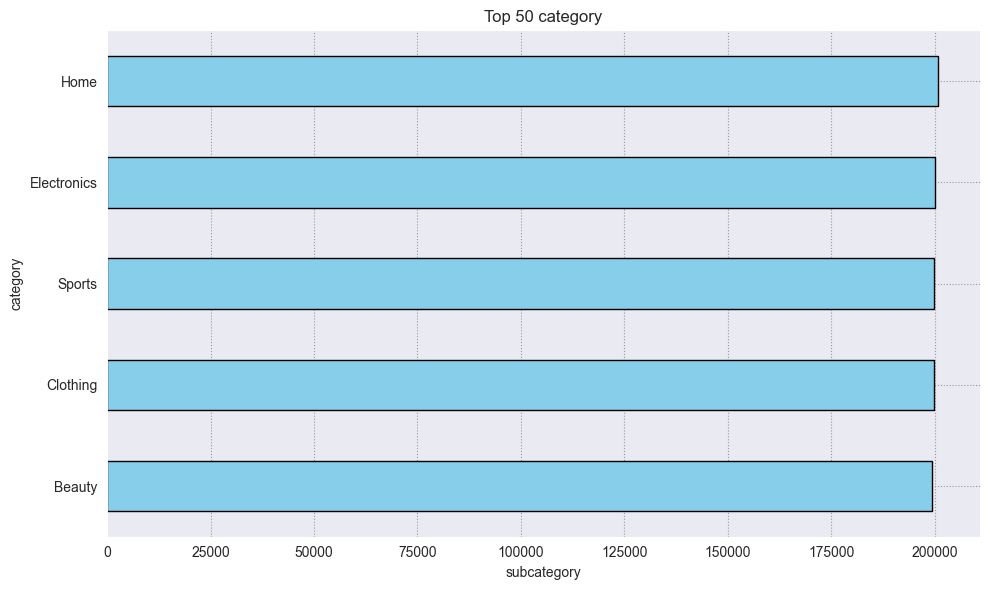

In [52]:
sns.set_style('darkgrid', {"grid.color": "0.6", "grid.linestyle": ":"})

category = df['category'].value_counts().head(10)

category = category.sort_values()

plt.figure(figsize=(10, 6))

category.plot(
    kind='barh',
    color='skyblue',
    edgecolor='black'
)

plt.title('Top 50 category')
plt.xlabel('subcategory')
plt.ylabel('category')

plt.tight_layout()
plt.show()

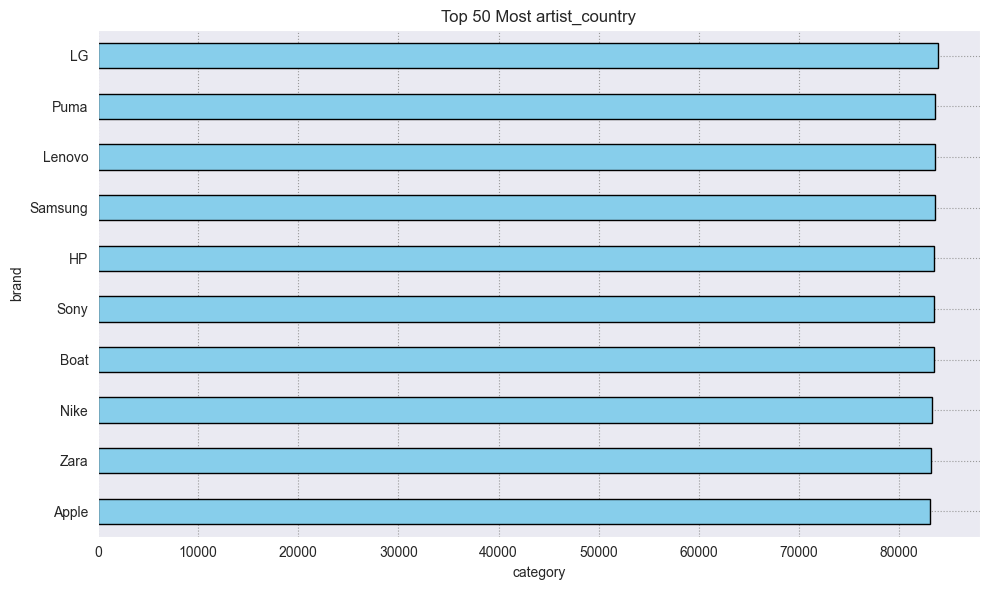

In [53]:
sns.set_style('darkgrid', {"grid.color": "0.6", "grid.linestyle": ":"})

brand = df['brand'].value_counts().head(10)

brand = brand.sort_values()

plt.figure(figsize=(10, 6))

brand.plot(
    kind='barh',
    color='skyblue',
    edgecolor='black'
)

plt.title('Top 50 Most artist_country')
plt.xlabel('category')
plt.ylabel('brand')

plt.tight_layout()
plt.show()

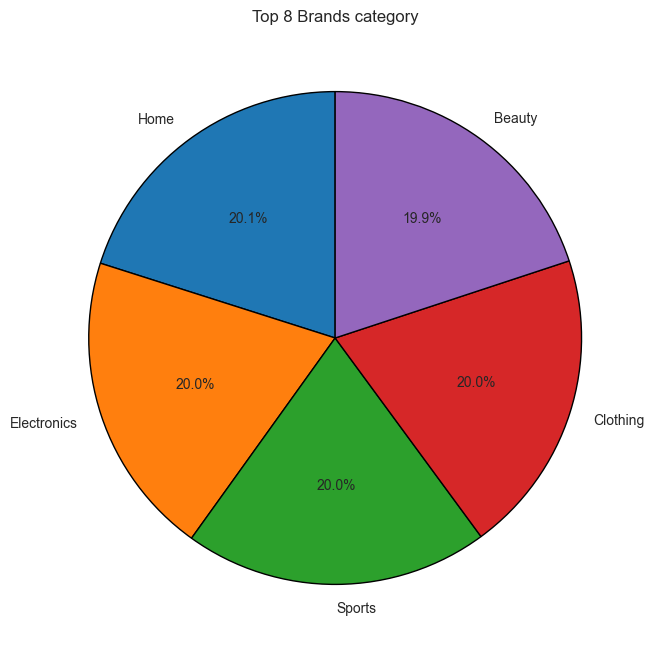

In [54]:
import matplotlib.pyplot as plt

top_brands = df['category'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands category')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

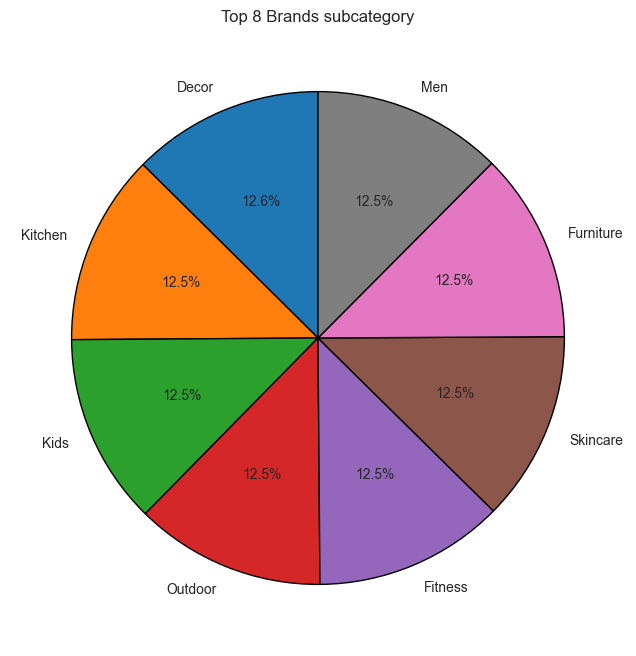

In [55]:
import matplotlib.pyplot as plt

top_brands = df['subcategory'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands subcategory')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

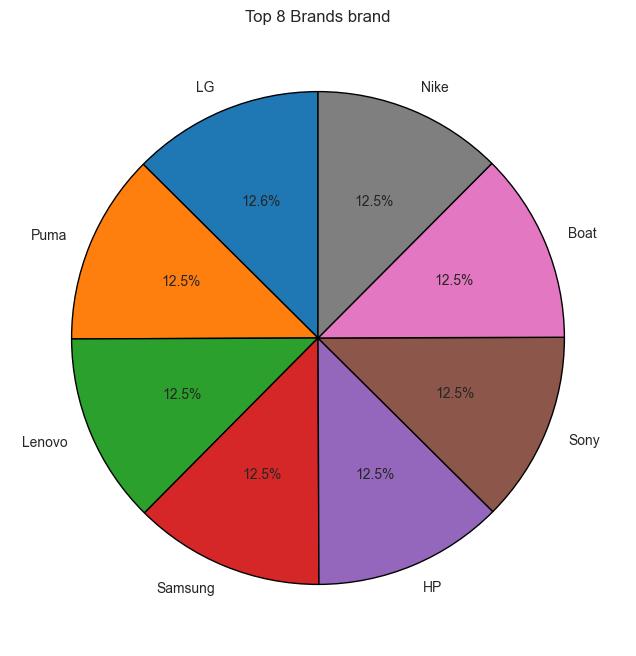

In [56]:
import matplotlib.pyplot as plt

top_brands = df['brand'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands brand')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

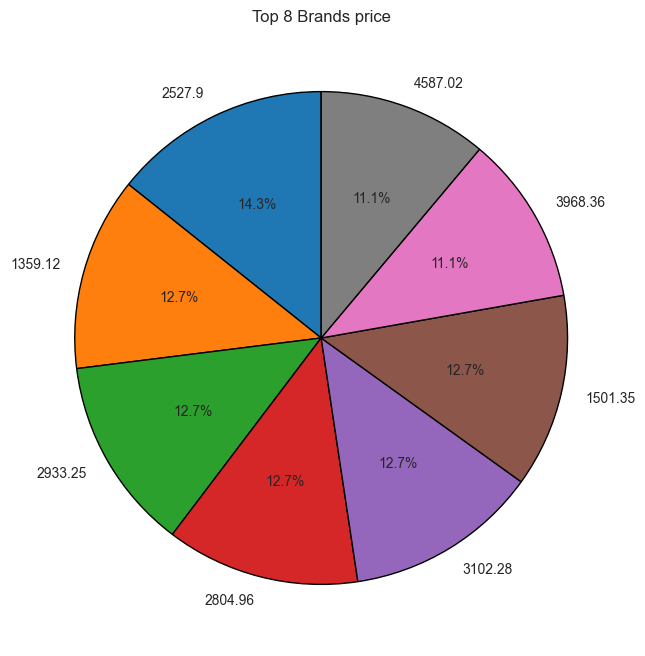

In [57]:
import matplotlib.pyplot as plt

top_brands = df['price'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands price')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

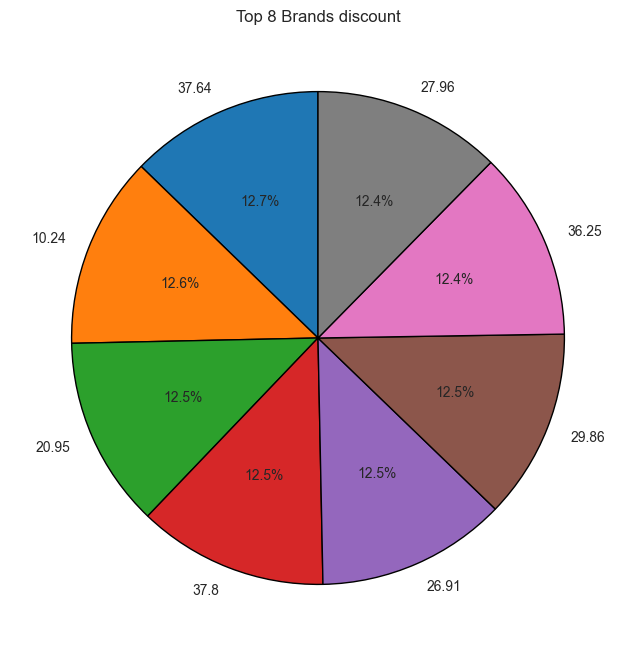

In [58]:
import matplotlib.pyplot as plt

top_brands = df['discount'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands discount')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

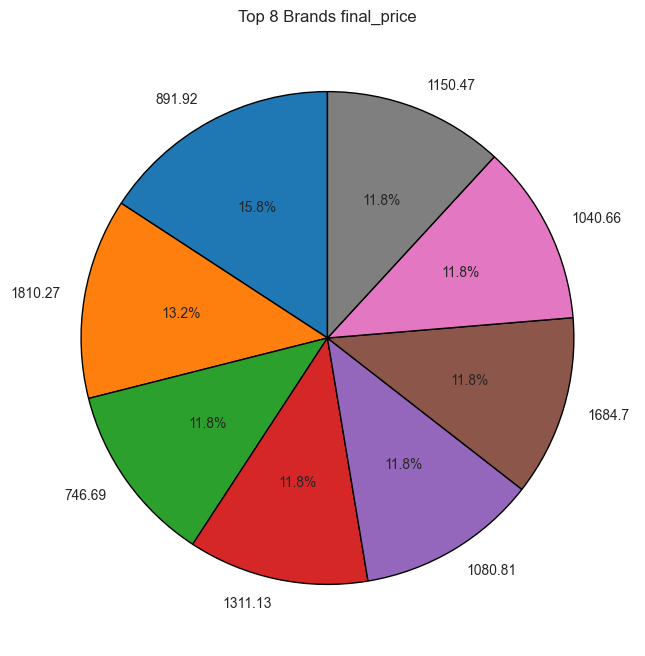

In [59]:
import matplotlib.pyplot as plt

top_brands = df['final_price'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands final_price')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

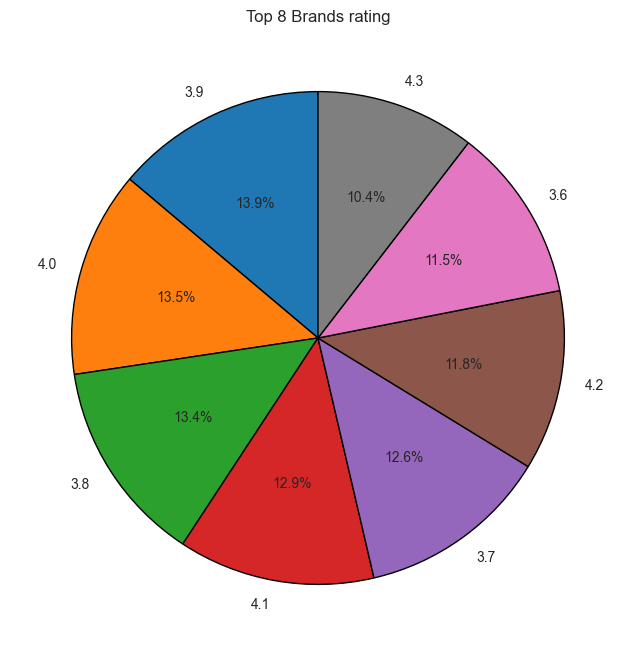

In [60]:
import matplotlib.pyplot as plt

top_brands = df['rating'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands rating')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

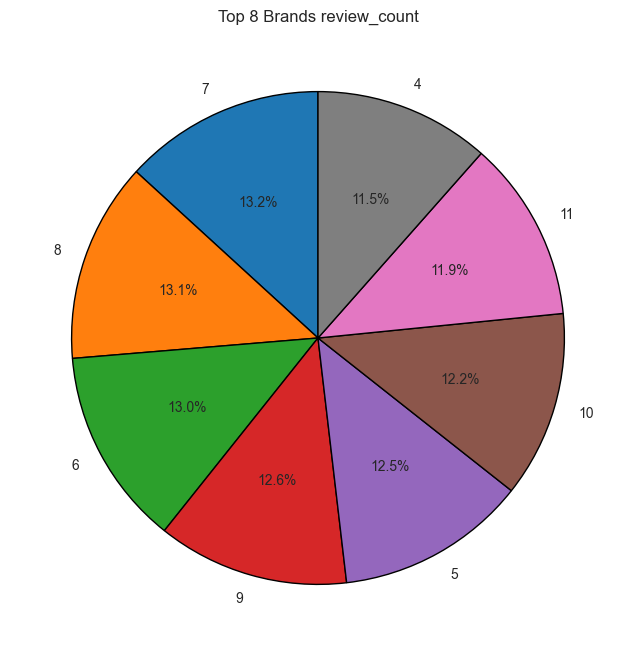

In [61]:
import matplotlib.pyplot as plt

top_brands = df['review_count'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands review_count')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

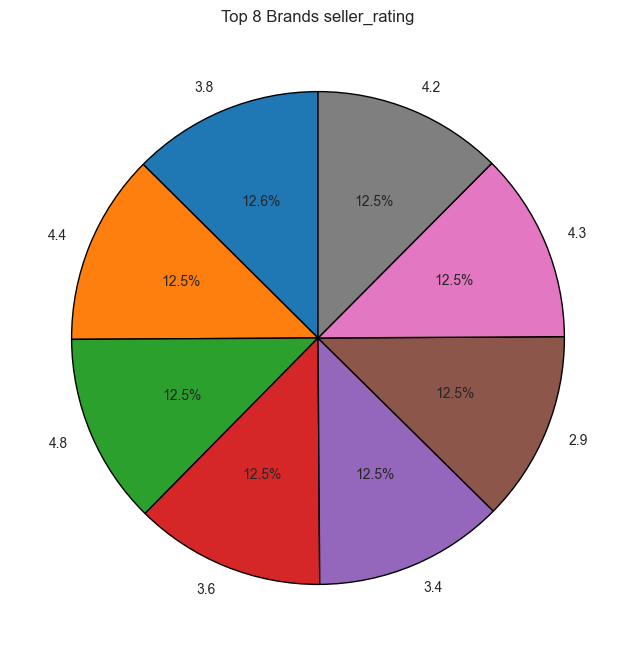

In [62]:
import matplotlib.pyplot as plt

top_brands = df['seller_rating'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands seller_rating')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

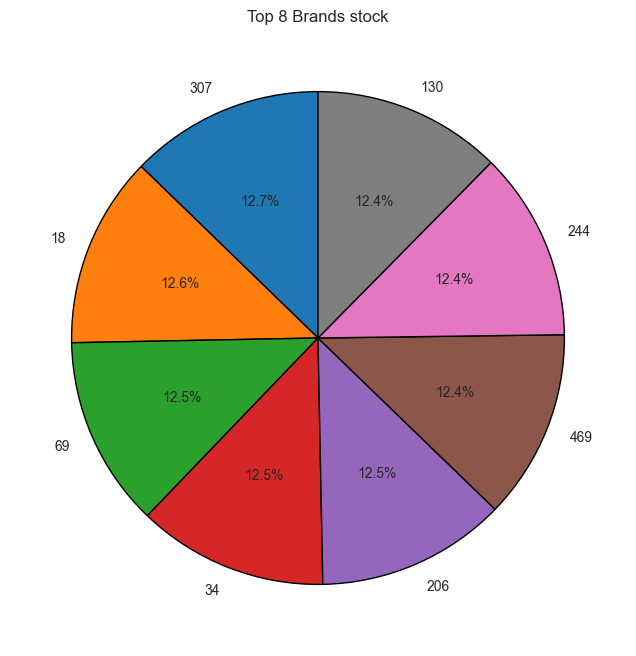

In [63]:
import matplotlib.pyplot as plt

top_brands = df['stock'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands stock')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

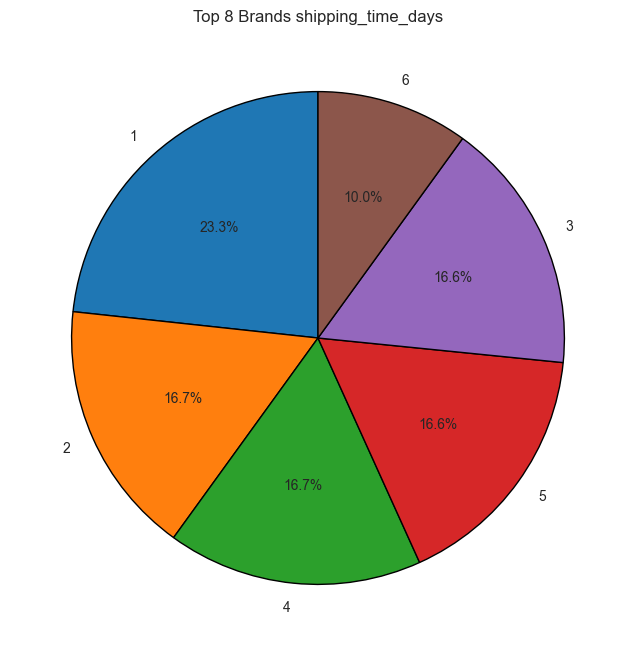

In [64]:
import matplotlib.pyplot as plt

top_brands = df['shipping_time_days'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands shipping_time_days')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

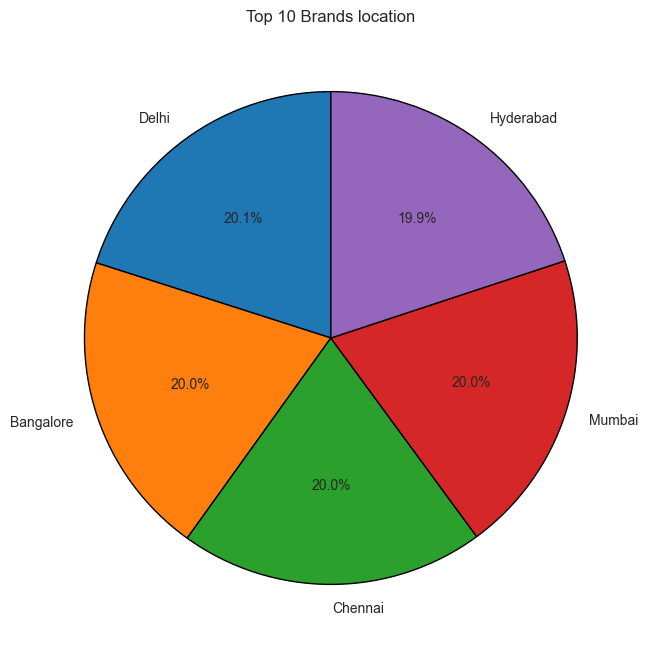

In [65]:
import matplotlib.pyplot as plt

top_brands = df['location'].value_counts().head(10)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 10 Brands location')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

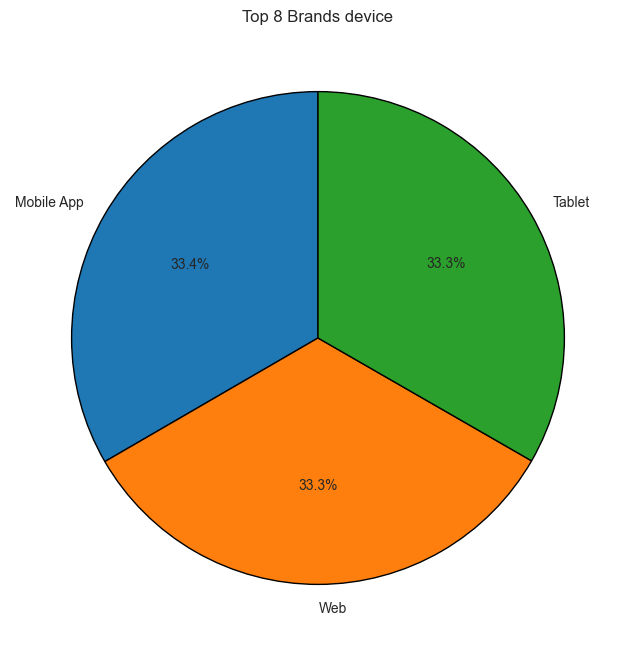

In [66]:
import matplotlib.pyplot as plt

top_brands = df['device'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands device')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

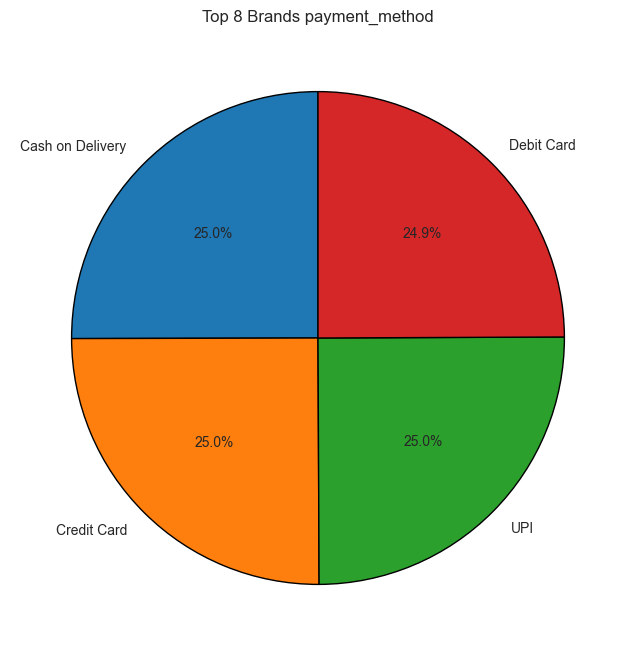

In [67]:
import matplotlib.pyplot as plt

top_brands = df['payment_method'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_brands.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,   # بيخلي الرسم أوضح
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top 8 Brands payment_method')

plt.ylabel('')  # لإزالة كلمة "brand" من النص
plt.show()

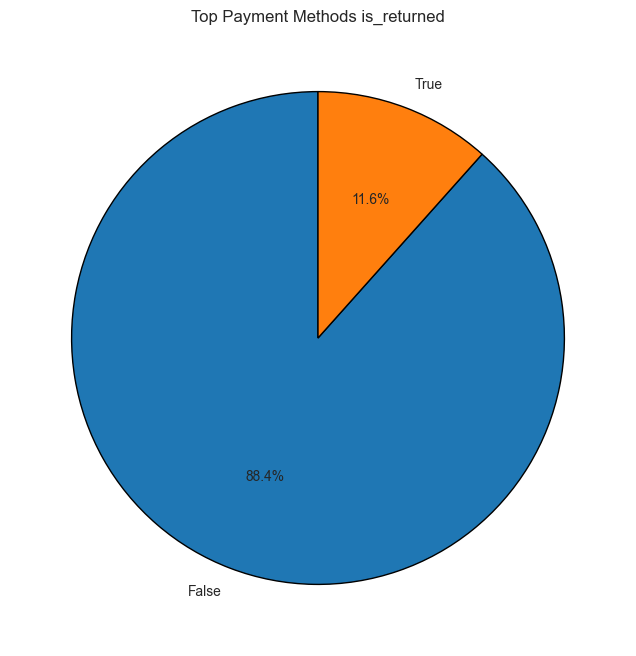

In [68]:
import matplotlib.pyplot as plt

top_methods = df['is_returned'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_methods.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top Payment Methods is_returned')

plt.ylabel('')
plt.show()

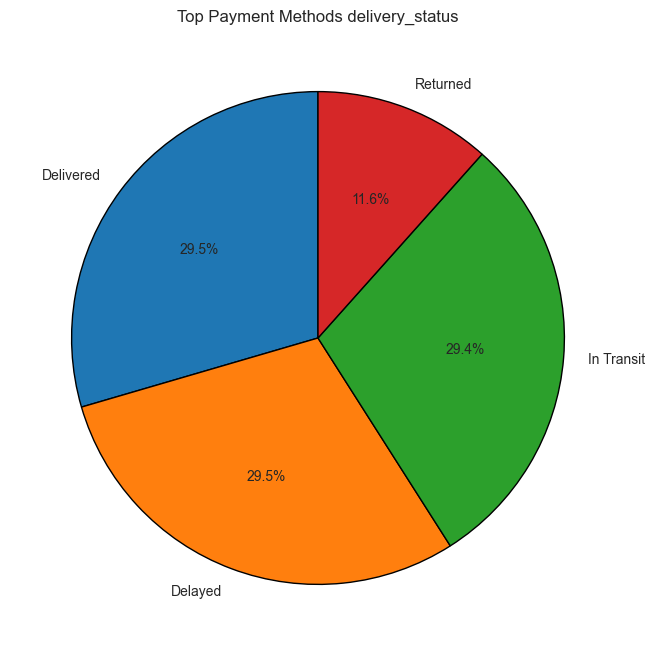

In [69]:
import matplotlib.pyplot as plt

top_methods = df['delivery_status'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_methods.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Top Payment Methods delivery_status')

plt.ylabel('')
plt.show()

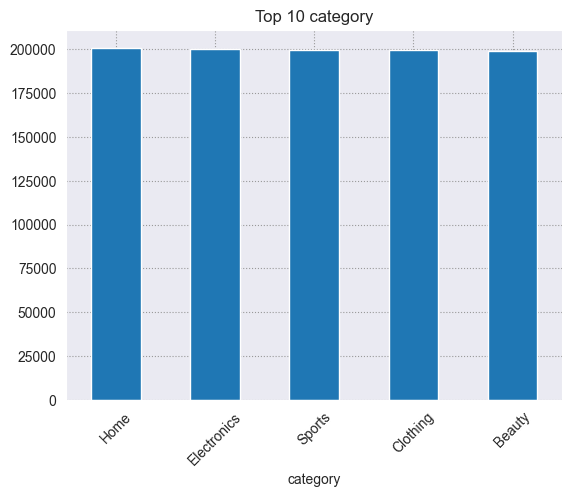

In [70]:
top_countries = df['category'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title('Top 10 category')
plt.xticks(rotation=45)
plt.show()

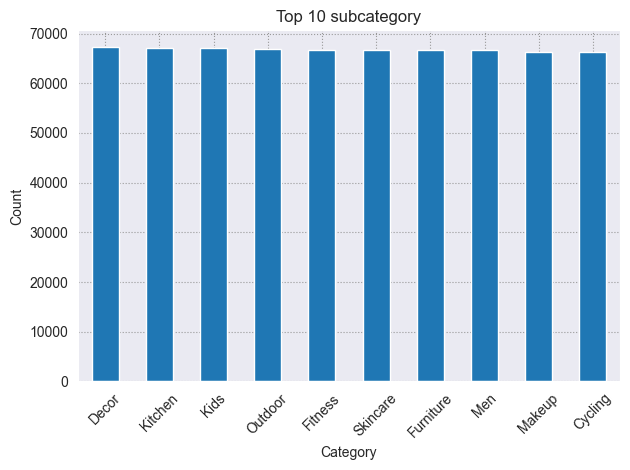

In [71]:
top_categories = df['subcategory'].value_counts().head(10)

top_categories.plot(kind='bar')

plt.title('Top 10 subcategory')
plt.xlabel('Category')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

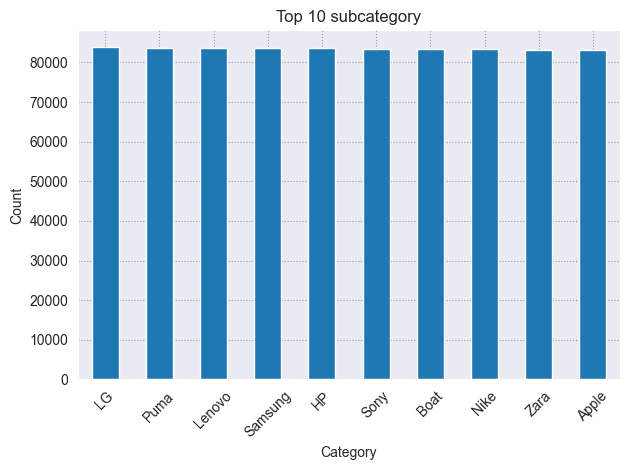

In [72]:
top_categories = df['brand'].value_counts().head(10)

top_categories.plot(kind='bar')

plt.title('Top 10 subcategory')
plt.xlabel('Category')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

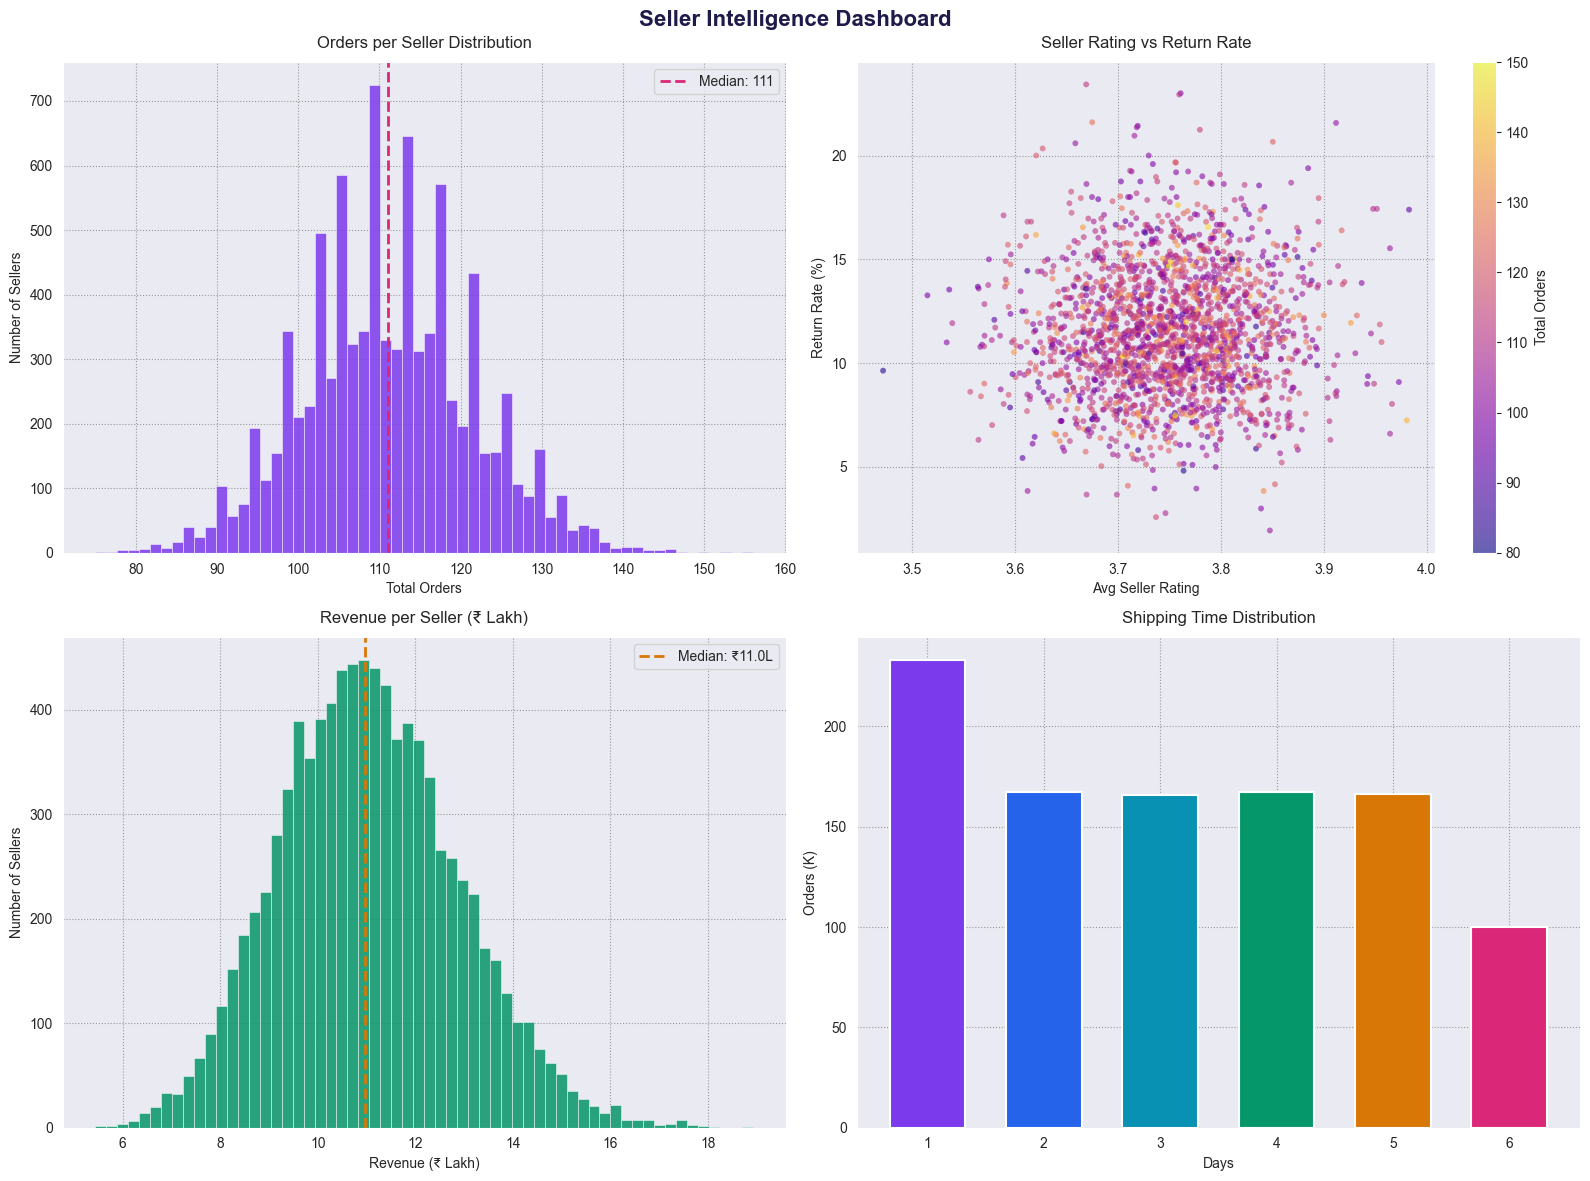

In [73]:
seller_stats = df.groupby('seller_id').agg(
    total_orders  = ('user_id', 'count'),
    total_revenue = ('final_price', 'sum'),
    avg_rating    = ('rating', 'mean'),
    avg_seller_r  = ('seller_rating', 'mean'),
    return_rate   = ('is_returned', 'mean'),
    avg_ship_days = ('shipping_time_days', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('white')
fig.suptitle('Seller Intelligence Dashboard', fontsize=16, fontweight='bold', color='#1e1b4b')

# Orders distribution
ax = axes[0,0]
ax.hist(seller_stats['total_orders'], bins=60, color='#7c3aed', edgecolor='white', linewidth=0.4, alpha=0.85)
ax.set_title('Orders per Seller Distribution', pad=10)
ax.set_xlabel('Total Orders')
ax.set_ylabel('Number of Sellers')
ax.axvline(seller_stats['total_orders'].median(), color='#db2777', linewidth=2, 
           linestyle='--', label=f"Median: {seller_stats['total_orders'].median():.0f}")
ax.legend()

# Seller rating vs return rate scatter
ax = axes[0,1]
sample = seller_stats.sample(min(2000, len(seller_stats)), random_state=42)
sc = ax.scatter(sample['avg_seller_r'], sample['return_rate']*100,
                c=sample['total_orders'], cmap='plasma', alpha=0.6, s=18, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Total Orders')
ax.set_title('Seller Rating vs Return Rate', pad=10)
ax.set_xlabel('Avg Seller Rating')
ax.set_ylabel('Return Rate (%)')

# Seller revenue distribution
ax = axes[1,0]
ax.hist(seller_stats['total_revenue']/1e5, bins=60, color='#059669', edgecolor='white', linewidth=0.4, alpha=0.85)
ax.set_title('Revenue per Seller (₹ Lakh)', pad=10)
ax.set_xlabel('Revenue (₹ Lakh)')
ax.set_ylabel('Number of Sellers')
ax.axvline(seller_stats['total_revenue'].median()/1e5, color='#d97706', linewidth=2,
           linestyle='--', label=f"Median: ₹{seller_stats['total_revenue'].median()/1e5:.1f}L")
ax.legend()

# Avg shipping days distribution
ax = axes[1,1]
ship_dist = df['shipping_time_days'].value_counts().sort_index()
ax.bar(ship_dist.index.astype(str), ship_dist.values/1000, 
       color=['#7c3aed','#2563eb','#0891b2','#059669','#d97706','#db2777'],
       edgecolor='white', linewidth=1.5, width=0.65)
ax.set_title('Shipping Time Distribution', pad=10)
ax.set_xlabel('Days')
ax.set_ylabel('Orders (K)')

plt.tight_layout()
plt.savefig('fig_seller_intel.png', dpi=150, bbox_inches='tight')
plt.show()

In [74]:
from sklearn.preprocessing import LabelEncoder

data = df[['category', 'subcategory']].dropna()

cat_encoder = LabelEncoder()
subcat_encoder = LabelEncoder()

data['category_enc'] = cat_encoder.fit_transform(data['category'])
data['subcategory_enc'] = subcat_encoder.fit_transform(data['subcategory'])

X = data[['category_enc']]
y = data['subcategory_enc']

In [75]:
import pandas as pd

data = df[['category', 'subcategory', 'brand']].dropna()

In [76]:
from sklearn.preprocessing import LabelEncoder

cat_encoder = LabelEncoder()
subcat_encoder = LabelEncoder()
brand_encoder = LabelEncoder()

data['category_enc'] = cat_encoder.fit_transform(data['category'])
data['subcategory_enc'] = subcat_encoder.fit_transform(data['subcategory'])
data['brand_enc'] = brand_encoder.fit_transform(data['brand'])

In [77]:
X = data[['category_enc', 'brand_enc']]
y = data['subcategory_enc']

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [79]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [80]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.3173


In [81]:
total_end = time.time()
print("Total runtime:", total_end - total_start, "seconds")

Total runtime: 48.796164989471436 seconds
